In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import moment
from scipy import stats
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm


from scipy.stats import linregress

import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.cm import ScalarMappable


from pylab import rcParams
rcParams['axes.labelweight'] = 'normal'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds


# Define constants
p0 = 1000  # reference pressure in hPa
R = 287.05  # specific gas constant for dry air in J/(kg*K)
cp = 1005  # specific heat at constant pressure for dry air in J/(kg*K)

def convert_to_potential_temperature(T, p):
    """
    Convert temperature to potential temperature.
    
    Parameters:
    T (xarray.DataArray): Temperature in K
    p (xarray.DataArray): Pressure in hPa
    
    Returns:
    xarray.DataArray: Potential temperature in K
    """
    return T * (p0 / p) ** (R / cp)


In [3]:
zoom = False

## Ocean Mask

In [105]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-20,20))
ocean_mask = masks.open_ocean.isin([2,3]) # mask for tropical indo-pacifi
#ocean_mask = masks.seamask # all tropical oceans

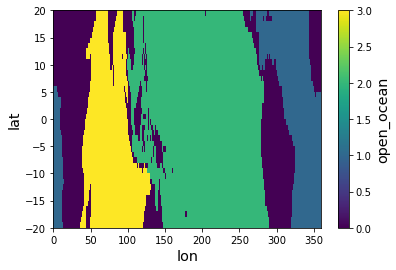

In [106]:
masks.open_ocean.plot()

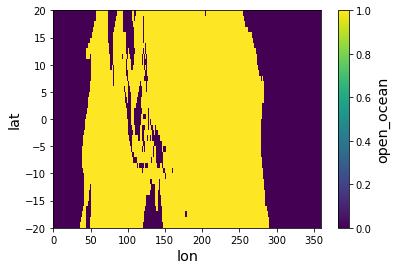

In [107]:
ocean_mask.plot()

# N

In [108]:
#all (Sw+lw) TOA; net and clear-sky. downward positive
fp = '/data/jmex/ERA5/monthly/rad_forcing/era5_n.nc'
n= xr.open_dataset(fp)

#change the longitude defintion to 0-360
n['longitude'] = (n['longitude']+360)%360
n = n.sortby('longitude')

#change the longitude defintion to 0-360
n = n.rename({'latitude':'lat', 'longitude':'lon'})
n = n.drop_vars(['number', 'expver'])

n = n.rename({'valid_time':'time'})


#over indo-pac only
n = n.where(ocean_mask)

In [109]:
#convert to w/m2
n = n/(60**2*24)
#total short and longwave
n['n'] = n.tsr+n.ttr

#weights
weights = np.cos(np.deg2rad(n.lat))

In [110]:
n_mean = n.weighted(weights).mean(['lat', 'lon'])
clim = n_mean.groupby('time.month').mean()
n_anom = n_mean.groupby('time.month')-clim

## Bar Code

In [111]:
#calculate mean over area (weighted)
#calculate yearly april-sept mean
n_mean = n.weighted(weights).mean(['lat', 'lon'])
n_mean = n_mean.where((n_mean.time.dt.month <=9) & (n_mean.time.dt.month >=4)).groupby('time.year').mean('time')

In [112]:
dn_mean = n_mean - n_mean.roll(year = 1)
dn_mean = dn_mean.sel(year = slice(1979, None))

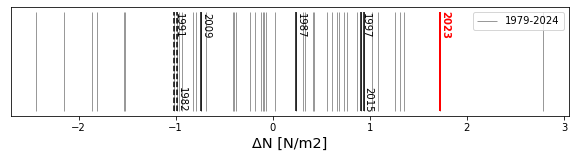

In [116]:

# Assuming dn_mean.n and dn_mean.year exist


composite_years = [1982, 1987, 1991, 1997,  2015, 2009]
dn_composite = dn_mean.where(dn_mean.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dn_mean.n, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dn_mean.sel(year = 1982).n, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1987).n, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 1991).n, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1997).n, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2009).n, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2015).n, ymin=0, ymax=1, color='black', linewidth=1.5)





for y in dn_composite.year.values: 
    x = dn_mean.sel(year = y).n
    if y in [1991, 1987, 1997, 2009]:
        ax.annotate(y, (x, 0.75), rotation = 270)
    else: 
        ax.annotate(y, (x, 0.), rotation = 270)
        

x = dn_mean.sel(year= 2023).n
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔN [N/m2]")
#ax.set_title("Barcode Plot of dn_mean.n")

plt.legend()
fig.savefig('Figures/Fig2j.png', dpi = 300, format = 'png', bbox_inches='tight')


In [14]:
#make rolling mean
n = n.rolling(time = 3, center = True, min_periods = 1).mean()

In [15]:
weights = np.cos(np.deg2rad(n.lat))

In [16]:
#total short and longwave
n['n'] = n.tsr+n.ttr

In [17]:
# Calculate climatology (1990-2020)
n['n_clim'] = n.sel(time=slice('1991-01-01', '2020-12-31')).groupby('time.month').mean('time').n

# Calculate anomalies
n['n_anom'] = n.n.groupby('time.month') - n.n_clim

In [18]:
y = 2023
sel1 = n.sel(time = str(y)).where((n.time.dt.month<=9)&(n.time.dt.month>=4)).mean('time')
sel2 = n.sel(time = str(y-1)).where((n.time.dt.month<=9)&(n.time.dt.month>=4)).mean('time')

delta_n23 = sel1-sel2

In [19]:
composite_years = [1982, 1987, 1991, 1997, 2015, 2009]

#select year 0s
n_sel1 = n.where((n.time.dt.year.isin(composite_years)) & (n.time.dt.month <= 9) &(n.time.dt.month>=4))
n_sel1 = n_sel1.mean('time')

#select year -1
n_sel2 = n.where((n.time.dt.year.isin([y-1 for y in composite_years])) & (n.time.dt.month <= 9)&(n.time.dt.month>=4))
n_sel2 = n_sel2.mean('time')


#compute delta
delta_ncomposite = n_sel1-n_sel2

In [20]:
composite_years = [1982, 1987, 1991, 1997,  2015, 2009]

#JantoSept
n_JS = n.where((n.time.dt.month <= 9)&(n.time.dt.month>=4), drop = True).n_anom
n_JS = n_JS.groupby('time.year').mean('time')


#take difference between years
diff_JS = n_JS - n_JS.roll(year = 1)

#select composite years
diff_JS = diff_JS.where(diff_JS.year.isin(composite_years), drop = True)


In [21]:
delta_ndiff = delta_n23 - delta_ncomposite

In [22]:
change = delta_ndiff.n_anom
a = delta_n23.n_anom
b = diff_JS

In [23]:
fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w500 = decode_time(fp).sel(lat = slice(20, -20))#,lon= slice(110, 260))

w500 = w500.where(ocean_mask)


In [24]:
w500 = w500.where((w500.time.dt.month<=9)& (w500.time.dt.month>=4)).groupby('time.year').mean('time')
w2023 = w500.sel(year = 2023)
wcomposite = w500.where(w500.year.isin(composite_years), drop = True).mean('year')
wdiff = w500.where(w500.year.isin(composite_years), drop = True).mean('year')


In [25]:
comparision = a>b
mask_all_five = comparision.all(dim = 'year')
mask_at_least_four = comparision.sum(dim = 'year') >=5

/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/xarray/plot/plot.py:1415: UserWarning: The following kwargs were not used by contour: 'label'
  primitive = ax.contour(x, y, z, **kwargs)
/tmp/ipykernel_821071/1821402783.py:150: UserWarning: linewidths is ignored by contourf
  ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,


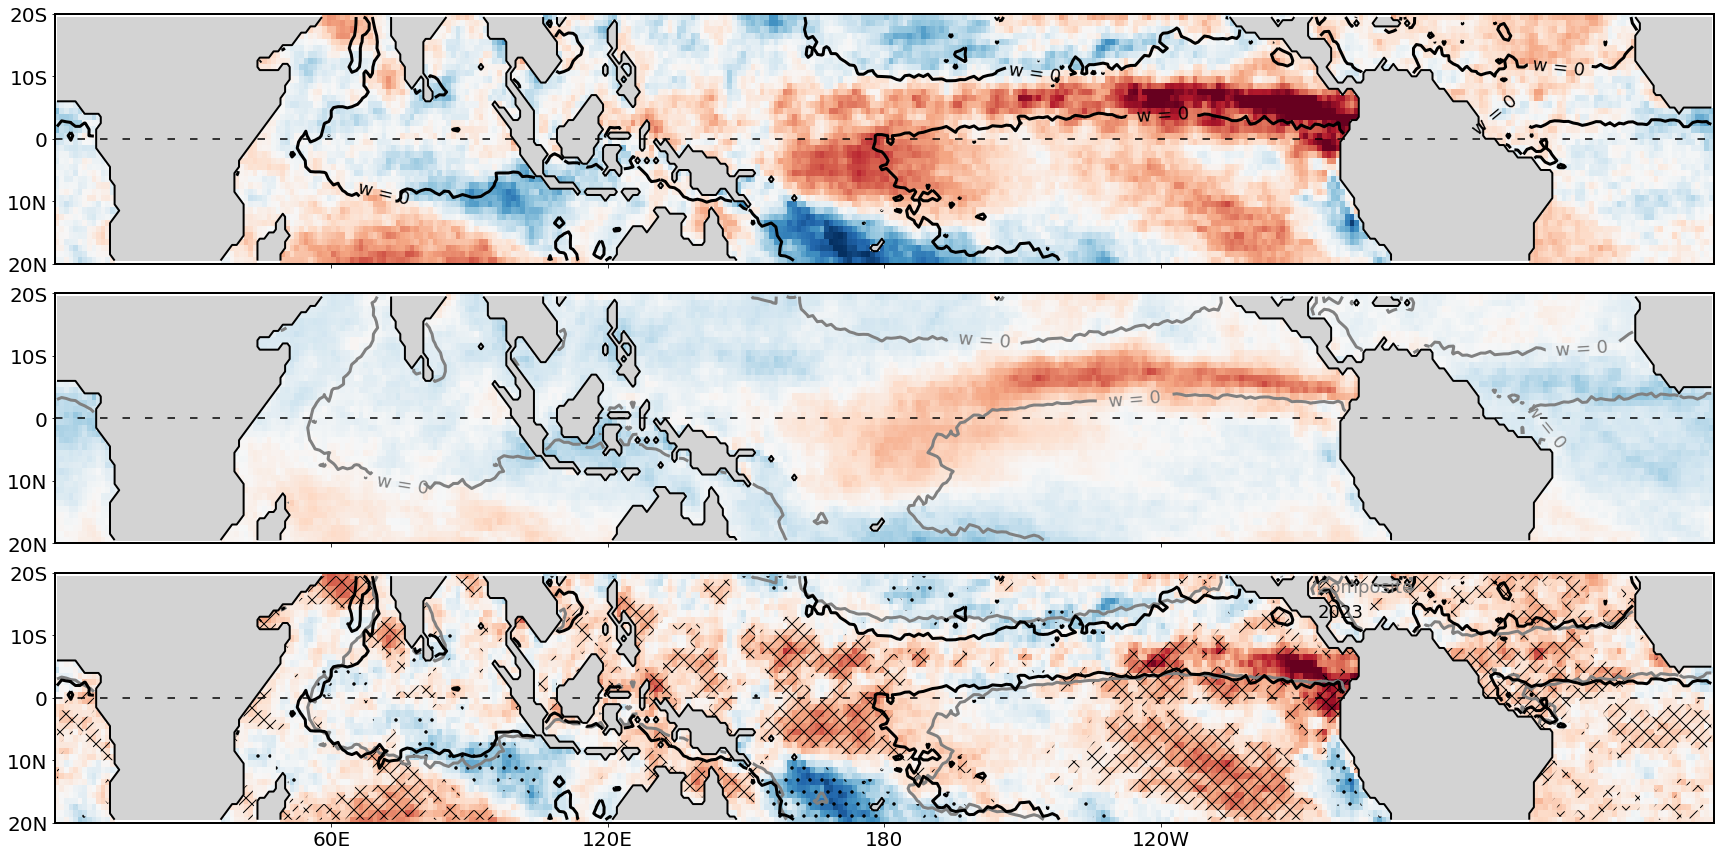

In [26]:
fig, axes = plt.subplots(3,1, figsize = (24,12), sharex = True)


# Define boundaries for discrete levels
bounds = np.linspace(-20,20 , 11)  # 10 discrete intervals between -20 and 20
norm = BoundaryNorm(boundaries=bounds, ncolors=18)

norm = mcolors.Normalize(vmin = -20, vmax = 20)

# Apply the colormap with the BoundaryNorm
cbar = delta_n23.n.plot(
    cmap='RdBu_r', 
    norm=norm, 
    ax=axes[0], 
    add_colorbar=False
)
#plt.colorbar(cbar, ax = axes[0], label = 'N Change [W/m2]')


axes[0].set_ylabel('Latitude')
axes[0].set_xlabel('')


# Plot the contour
CS1 = w2023.w.plot.contour(levels=[-0.0], ax=axes[0], colors= 'k', linewidths = 3)
axes[0].clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=18)
axes[0].set_title('')


#-----------------------------
# Apply the colormap with the BoundaryNorm
cbar = delta_ncomposite.n.plot(
    cmap='RdBu_r', 
    norm=norm, 
    ax=axes[1], 
    add_colorbar=False
)
#plt.colorbar(cbar, ax = axes[1], label = 'N Change [W/m2]')

# Plot the contour
CS1 = wcomposite.w.plot.contour(levels=[-0.0], ax=axes[1], colors = 'grey', linewidths = 3)
axes[1].clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=18)


axes[1].set_ylabel('Latitude')
axes[1].set_xlabel('')
axes[1].set_title('')



#-----------------------------
# Apply the colormap with the BoundaryNorm
cbar = delta_ndiff.n.plot(
    cmap='RdBu_r', 
    norm=norm, 
    ax=axes[2], 
    add_colorbar=False
)

# Plot the contour
CS1 = wcomposite.w.plot.contour(levels=[-0.0], ax=axes[2], label = 'composite', colors = 'grey', linewidths = 3)
CS2 = w2023.w.plot.contour(levels=[-0.0], ax=axes[2], colors = 'k', label = '2023', linewidths = 3)
#axes[2].clabel(CS1, CS1.levels, inline=True, fmt={0:'composite'}, fontsize=12);
#axes[2].clabel(CS2, CS2.levels, inline=True, fmt={0:'2023'}, fontsize=12);
axes[2].set_title('')
#fig.colorbar(cbar, orientation = 'horizontal', extend = 'both', label = 'ΔN [W/m2]')




#------------------significance masking positive
comparision = a>b
mask_all_five = comparision.all(dim = 'year')
mask_at_least_four = comparision.sum(dim = 'year') >=5
# Add diagonal hatching for significant regions
axes[2].contourf(
    change.lon, change.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)
axes[2].contourf(
    change.lon, change.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['//'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


"""
# Add diagonal hatching for significant regions
axes[2].contourf(
    change.lon, change.lat, mask_at_least_four,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)"""

#------------------significance masking negative

comparision = a<b
mask_all_five = comparision.all(dim = 'year')
mask_at_least_four = comparision.sum(dim = 'year') >=5
"""# Add diagonal hatching for significant regions
axes[2].contourf(
    change.lon, change.lat, mask_at_least_four,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['..'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)"""

# Add diagonal hatching for significant regions
axes[2].contourf(
    change.lon, change.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['.'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


for ax in axes: 
    #ax.set_xlim(40, 290)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticks(ax.get_yticks()[::2])
    
    xtick_position = [60, 120, 180, 240] 
    xtick_labels = [ '60E', '120E', '180', '120W']
    ax.set_xticks(ticks = xtick_position,)
    ax.set_xticklabels(xtick_labels, fontsize = 20)
    ax.set_yticklabels(['20N', '10N', '0', '10S', '20S'], fontsize=20)
    
#    ax.spines[:].set_visible(False)
    ax.spines[:].set_linewidth(2)

#contours for ocean
for ax in axes:  
    ax.contour(ocean_mask.lon, ocean_mask.lat, ocean_mask,
               levels=[0.5], colors='black', linewidths=2)
    ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,
                   levels=[0,0.5], colors='lightgrey', linewidths=2)


    
# Manually add a text box with "Composite" in grey and "2023" in black
axes[2].text(274, 17, "Composite", color="grey", fontsize=18, fontweight="normal")
axes[2].text(274, 13, "2023", color="black", fontsize=18, fontweight="normal")

#equator lines
axes[0].axhline(0, linestyle=(0, (5, 10)), c = 'k')
axes[1].axhline(0, linestyle=(0, (5, 10)), c = 'k')
axes[2].axhline(0, linestyle=(0, (5, 10)), c = 'k')


plt.tight_layout()
fig.savefig('Figures/Fig2d.png', dpi = 300, format = 'png')


/tmp/ipykernel_821071/2031872079.py:2: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  plt.colorbar(cbar, orientation = 'vertical', extend = 'both', label = 'ΔN [W/m2]')


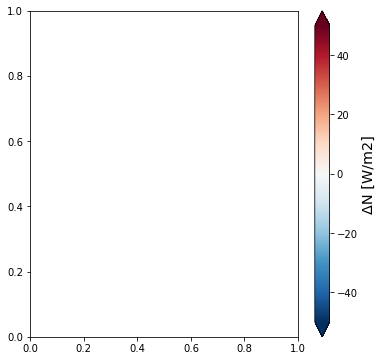

In [118]:
plt.figure(figsize = (6,6))
plt.colorbar(cbar, orientation = 'vertical', extend = 'both', label = 'ΔN [W/m2]')
plt.savefig('Figures/Fig2dcbar.png', dpi = 300, format = 'png')


# SST change

In [28]:
fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w500 = decode_time(fp).sel(lat = slice(20, -20))#,lon= slice(110, 260))

w500 = w500.where(ocean_mask)


In [29]:
w500 = w500.where((w500.time.dt.month<=9)& (w500.time.dt.month>=4)).groupby('time.year').mean('time')
w2023 = w500.sel(year = 2023)
wcomposite = w500.where(w500.year.isin(composite_years), drop = True).mean('year')
wdiff = w500.where(w500.year.isin(composite_years), drop = True).mean('year')


In [30]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(20,-20)).where(ocean_mask)

In [31]:
weights = np.cos(np.deg2rad(sst.lat))

#yearly average Jan-Sept
sst_y = sst.where((sst.time.dt.month<=9) & (sst.time.dt.month>=4)).groupby('time.year').mean()

#change in sst_y
d_sst = sst_y - sst_y.roll(year = 1)


In [32]:
d_2023 = d_sst.sel(year = 2023)


In [33]:
d_composite = d_sst.where(d_sst.year.isin(composite_years), drop = True)

In [34]:
diff = d_2023-d_composite.mean('year')


## mask to check comparision

In [35]:
comparision = d_2023.sst>d_composite.sst
mask_all_five = comparision.all(dim = 'year')
mask_at_least_four = comparision.sum(dim = 'year') >=5

/tmp/ipykernel_821071/3839957135.py:100: UserWarning: linewidths is ignored by contourf
  ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,


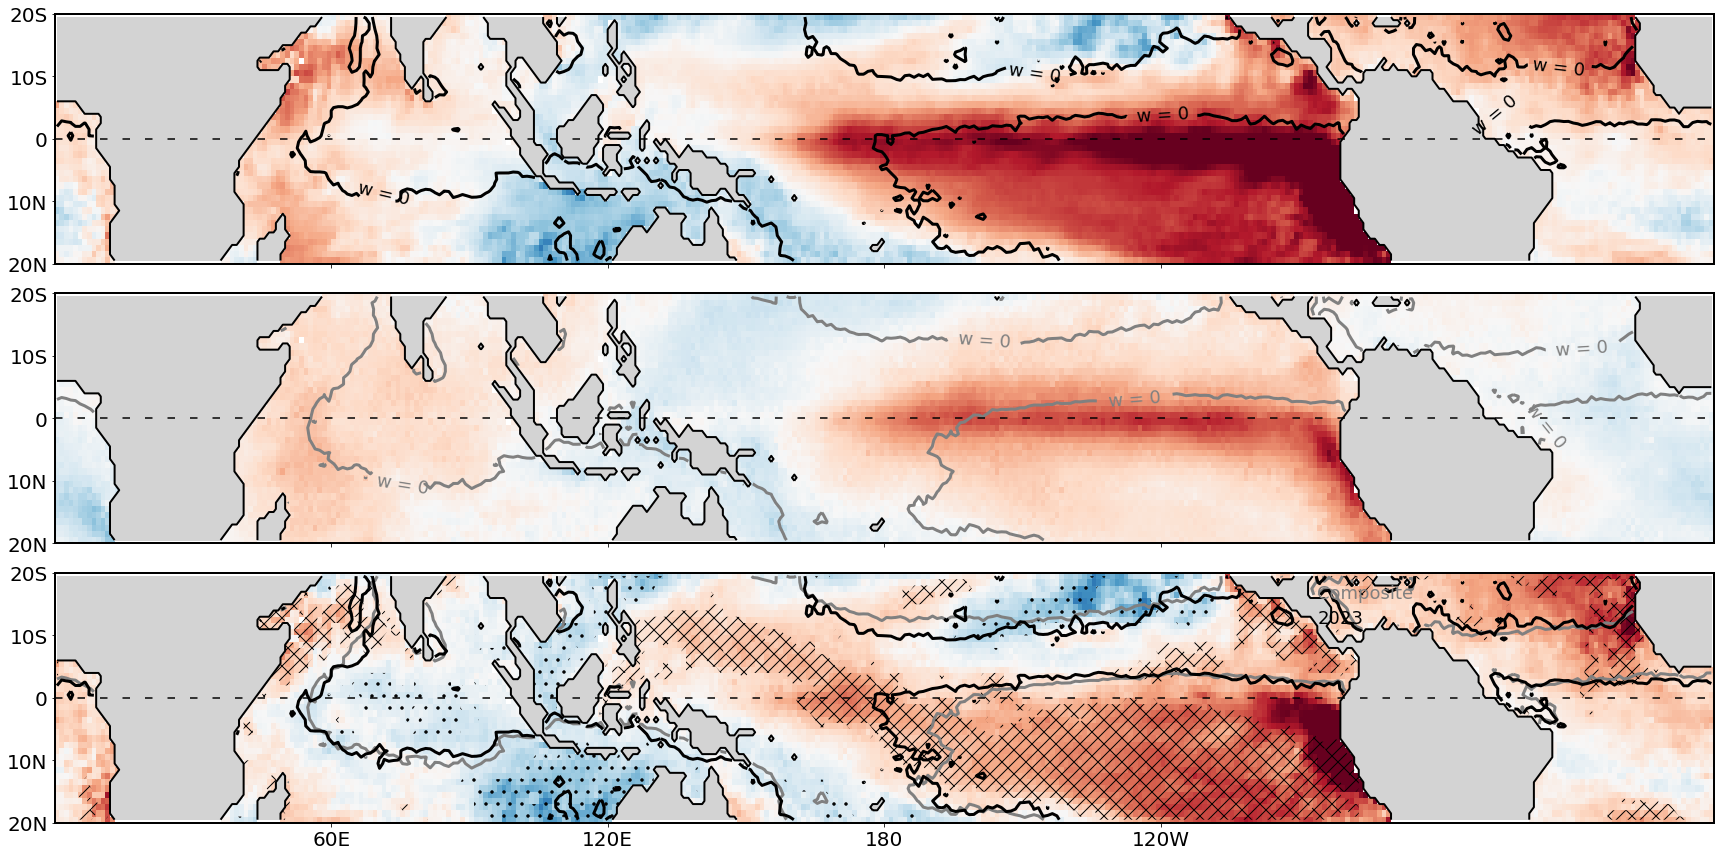

In [36]:
fig, axes = plt.subplots(3,1, figsize = (24,12), sharex = True)


cbar = d_2023.sst.plot(cmap = 'RdBu_r', vmin = -2, vmax = 2, ax = axes[0], add_colorbar = False)

# Plot the contour
CS1 = w2023.w.plot.contour(levels=[-0.0], ax=axes[0], colors = 'k', linewidths = 3)
axes[0].clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=18)
axes[0].set_title('')

#-----------------------------


cbar = d_composite.mean('year').sst.plot(cmap = 'RdBu_r', vmin = -2, vmax = 2,add_colorbar = False, ax = axes[1])

# Plot the contour
CS1 = wcomposite.w.plot.contour(levels=[-0.0], ax=axes[1], colors = 'grey', linewidths = 3)
axes[1].clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=18)
axes[1].set_title('')

#---------------------
cbar = diff.sst.plot(cmap = 'RdBu_r', vmin = -2, vmax = 2, add_colorbar = False)#label=r'$\Delta SST [K]$')

# Plot the contour
CS1 = wcomposite.w.plot.contour(levels=[-0.0], ax=axes[2], colors = 'grey', linewidths = 3)
CS2 = w2023.w.plot.contour(levels=[-0.0], ax=axes[2], colors = 'k', linewidths = 3)
#axes[2].clabel(CS1, CS1.levels, inline=True, fmt={0:'composite'}, fontsize=12);
#axes[2].clabel(CS2, CS2.levels, inline=True, fmt={0:'2023'}, fontsize=12);
axes[2].set_title('')

#------------------significance masking psotive
comparision = d_2023.sst>d_composite.sst
mask_all_five = comparision.all(dim = 'year')
mask_at_least_four = comparision.sum(dim = 'year') >=5

# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['//'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)
plt.contourf(
    diff.lon, diff.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


"""# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_at_least_four,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)"""


#------------------significance masking negatie
comparision = d_2023.sst<d_composite.sst
mask_all_five = comparision.all(dim = 'year')
mask_at_least_four = comparision.sum(dim = 'year') >=5

# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['.'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)

for ax in axes: 
    #ax.set_xlim(40, 290)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticks(ax.get_yticks()[::2])
    
    xtick_position = [60, 120, 180, 240] 
    xtick_labels = [ '60E', '120E', '180', '120W']
    ax.set_xticks(ticks = xtick_position,)
    ax.set_xticklabels(xtick_labels, fontsize = 20)
    ax.set_yticklabels(['20N', '10N', '0', '10S', '20S'], fontsize=20)
    
    #ax.spines[:].set_visible(False)
    ax.spines[:].set_linewidth(2)

#contours for ocean
for ax in axes:  
    ax.contour(ocean_mask.lon, ocean_mask.lat, ocean_mask,
               levels=[0.5], colors='black', linewidths=2)
    ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,
                   levels=[0,0.5], colors='lightgrey', linewidths=2)


    
    
# Manually add a text box with "Composite" in grey and "2023" in black
axes[2].text(274, 16, "Composite", color="grey", fontsize=18, fontweight="normal")
axes[2].text(274, 12, "2023", color="black", fontsize=18, fontweight="normal")

#equator lines
axes[0].axhline(0, linestyle=(0, (5, 10)), c = 'k')
axes[1].axhline(0, linestyle=(0, (5, 10)), c = 'k')
axes[2].axhline(0, linestyle=(0, (5, 10)), c = 'k')


plt.tight_layout()
fig.savefig('Figures/Fig2a.png', dpi = 300, format = 'png')


/tmp/ipykernel_821071/722213730.py:2: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  plt.colorbar(cbar, extend = 'both', label = 'ΔSST [K]')


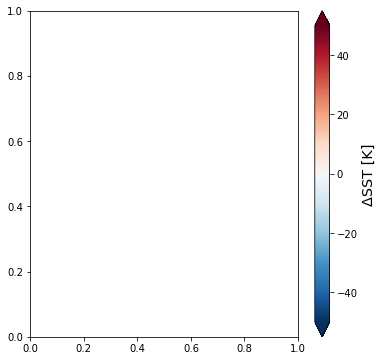

In [117]:
plt.figure(figsize = (6,6))
plt.colorbar(cbar, extend = 'both', label = 'ΔSST [K]')
plt.savefig('Figures/Fig2acbar.png', dpi = 300, format = 'png')


## CERES

In [119]:
fp = '/data/jmex/CERES/CERES_TOA.nc'
ceres = xr.open_dataset(fp).where(ocean_mask)

clim = ceres.sel(time = slice('1991', '2020')).groupby('time.month').mean()
ceres_anom = ceres.groupby('time.month') - clim
ceres_anom = ceres_anom.rolling(time = 3, center = True, min_periods = 1).mean()

In [120]:
y = 2023
sel1 = ceres_anom.sel(time = str(y)).where((ceres_anom.time.dt.month<=9)&(ceres_anom.time.dt.month>=4)).mean('time')
sel2 = ceres_anom.sel(time = str(y-1)).where((ceres_anom.time.dt.month<=9)&(ceres_anom.time.dt.month>=4)).mean('time')

delta_ceres = sel1-sel2

/tmp/ipykernel_821071/1231093196.py:40: UserWarning: linewidths is ignored by contourf
  ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,


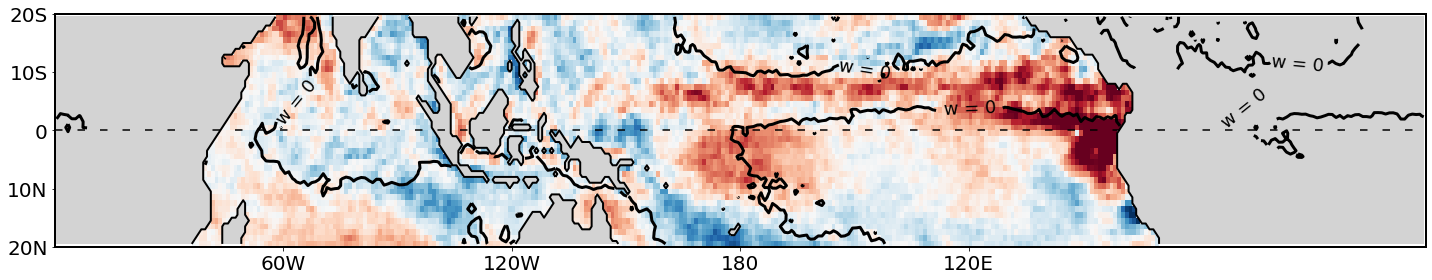

In [121]:
fig, ax = plt.subplots(1,1, figsize = (20,4))


norm = mcolors.Normalize(vmin = -20, vmax = 20)

# Apply the colormap with the BoundaryNorm

cbar = delta_ceres.toa_net_all_mon.plot(
    cmap='RdBu_r', 
    norm=norm, 
    ax=ax, 
    add_colorbar=False
)

CS1 = w2023.w.plot.contour(levels=[-0.0], ax=ax, colors = 'k', linewidths = 3)
ax.clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=18)
ax.set_title('')
#plt.colorbar(cbar, ax = ax, label = 'N Change [W/m2]')


#fig.colorbar(cbar, orientation = 'horizontal', extend = 'both', label = 'ΔN [W/m2]')


for ax in [ax]: 
    #ax.set_xlim(40, 290)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticks(ax.get_yticks()[::2])
    
    xtick_position = [60, 120, 180, 240] 
    xtick_labels = [ '60W', '120W', '180', '120E']
    ax.set_xticks(ticks = xtick_position,)
    ax.set_xticklabels(xtick_labels, fontsize = 20)
    ax.set_yticklabels(['20N', '10N', '0', '10S', '20S'], fontsize=20)
    
    #ax.spines[:].set_visible(False)
    ax.spines[:].set_linewidth(2)

#contours for ocean
ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,
               levels=[0,0.5], colors='lightgrey', linewidths=2)
ax.contour(ocean_mask.lon, ocean_mask.lat, ocean_mask,
               levels=[0.5], colors='k', linewidths=2)

ax.axhline(0, linestyle=(0, (5, 10)), c = 'k')



plt.tight_layout()
fig.savefig('Figures/FigS4.png', dpi = 300, format = 'png')


/tmp/ipykernel_821071/1700901179.py:1: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  plt.colorbar(cbar, orientation = 'horizontal', extend = 'both', label = 'ΔN [W/m2]')


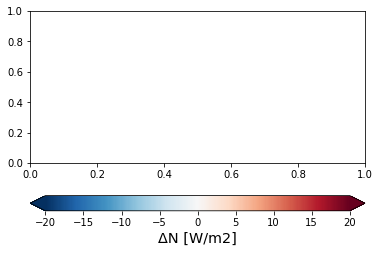

In [122]:
plt.colorbar(cbar, orientation = 'horizontal', extend = 'both', label = 'ΔN [W/m2]')
plt.savefig('Figures/FigS4cbar.png', dpi = 300, format = 'png')




# LCC Map

In [73]:
fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w500 = decode_time(fp).sel(lat = slice(20, -20))#,lon= slice(110, 260))

w500 = w500.where(ocean_mask)


In [74]:
w500 = w500.where((w500.time.dt.month<=9)& (w500.time.dt.month>=4)).groupby('time.year').mean('time')
w2023 = w500.sel(year = 2023)
wcomposite = w500.where(w500.year.isin(composite_years), drop = True).mean('year')
wdiff = w500.where(w500.year.isin(composite_years), drop = True).mean('year')


In [75]:

fp  = '/data/jmex/ERA5/monthly/clouds/era5_clouds.nc'

clouds = xr.open_dataset(fp).sel(latitude = slice(20, -20), valid_time = slice('1979', '2024-10'))

clouds = clouds.drop(['expver', 'number'])
clouds = clouds.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})
clouds['lon'] = (clouds['lon']+360)%360
clouds = clouds.sortby('lon')

In [76]:
lcc = clouds.where(ocean_mask)#.drop_vars(['lcc', 'mcc', 'tcc'])

In [77]:
weights = np.cos(np.deg2rad(lcc.lat))

#yearly average Jan-Sept
lcc_y = lcc.where((lcc.time.dt.month<9) & (lcc.time.dt.month>=4)).groupby('time.year').mean()

#change in lcc_y
d_lcc = lcc_y - lcc_y.roll(year = 1)

In [78]:
clim = lcc_y.sel(year = slice('1991', '2020')).mean('year')

In [79]:
d_2023 = d_lcc.sel(year = 2023)
#d_2023 = 100*d_2023/clim.lcc


In [80]:
d_composite = d_lcc.where(d_lcc.year.isin(composite_years), drop = True)
#d_composite = 100*d_composite/clim.lcc

In [81]:
diff = d_2023-d_composite.mean('year')


## mask to check comparision

In [82]:
comparision = d_2023.lcc<d_composite.lcc
mask_all_five = comparision.all(dim = 'year')
mask_at_least_four = comparision.sum(dim = 'year') >=5

In [83]:
comparision_high = d_2023.lcc>d_composite.lcc
mask_all_five_high = comparision_high.all(dim = 'year')
mask_at_least_four_high = comparision_high.sum(dim = 'year') >=5

/tmp/ipykernel_821071/3355892296.py:94: UserWarning: linewidths is ignored by contourf
  ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,


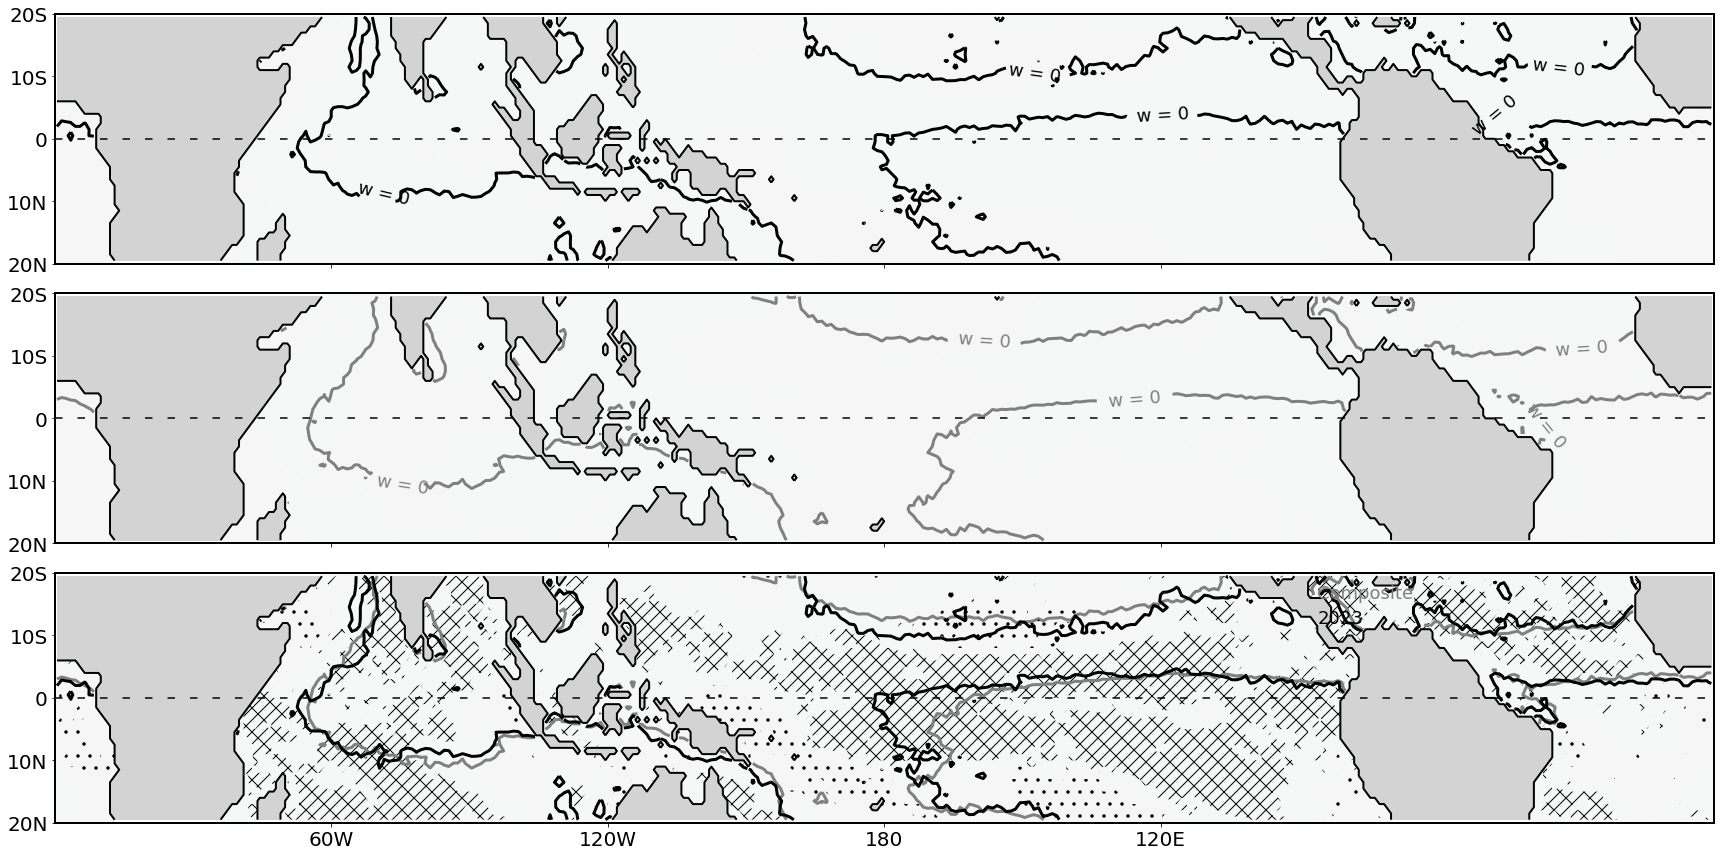

In [84]:
fig, axes = plt.subplots(3,1, figsize = (24,12), sharex = True)


cbar = d_2023.lcc.plot(cmap = 'RdBu_r', vmin = -50, vmax = 50, ax = axes[0], add_colorbar = False)

# Plot the contour
CS1 = w2023.w.plot.contour(levels=[-0.0], ax=axes[0], colors = 'k', linewidths = 3)
axes[0].clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=18)
axes[0].set_title('')

#-----------------------------


cbar = d_composite.mean('year').lcc.plot(cmap = 'RdBu_r', vmin = -50, vmax = 50,add_colorbar = False, ax = axes[1])

# Plot the contour
CS1 = wcomposite.w.plot.contour(levels=[-0.0], ax=axes[1], colors = 'grey', linewidths = 3)
axes[1].clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=18)
axes[1].set_title('')

#---------------------
cbar = diff.lcc.plot(cmap = 'RdBu_r', vmin = -50, vmax = 50, add_colorbar = False)#label=r'$\Delta lcc [K]$')

# Plot the contour
CS1 = wcomposite.w.plot.contour(levels=[-0.0], ax=axes[2], colors = 'grey', linewidths = 3)
CS2 = w2023.w.plot.contour(levels=[-0.0], ax=axes[2], colors = 'k', linewidths = 3)
#axes[2].clabel(CS1, CS1.levels, inline=True, fmt={0:'composite'}, fontsize=12);
#axes[2].clabel(CS2, CS2.levels, inline=True, fmt={0:'2023'}, fontsize=12);
axes[2].set_title('')

#------------------significance masking

# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['//'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)

# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_all_five_high,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['.'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


"""# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_at_least_four_high,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['.'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)
"""
for ax in axes: 
    #ax.set_xlim(40, 290)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticks(ax.get_yticks()[::2])
    
    xtick_position = [60, 120, 180, 240] 
    xtick_labels = [ '60W', '120W', '180', '120E']
    ax.set_xticks(ticks = xtick_position,)
    ax.set_xticklabels(xtick_labels, fontsize = 20)
    ax.set_yticklabels(['20N', '10N', '0', '10S', '20S'], fontsize=20)
    
    #ax.spines[:].set_visible(False)
    ax.spines[:].set_linewidth(2)

#contours for ocean
for ax in axes:  
    ax.contour(ocean_mask.lon, ocean_mask.lat, ocean_mask,
               levels=[0.5], colors='black', linewidths=2)
    ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,
                   levels=[0,0.5], colors='lightgrey', linewidths=2)


    
    
# Manually add a text box with "Composite" in grey and "2023" in black
axes[2].text(274, 16, "Composite", color="grey", fontsize=18, fontweight="normal")
axes[2].text(274, 12, "2023", color="black", fontsize=18, fontweight="normal")

#equator lines
axes[0].axhline(0, linestyle=(0, (5, 10)), c = 'k')
axes[1].axhline(0, linestyle=(0, (5, 10)), c = 'k')
axes[2].axhline(0, linestyle=(0, (5, 10)), c = 'k')


plt.tight_layout()
fig.savefig('Figures/FigS3a.png', dpi = 600, format = 'png')


/tmp/ipykernel_821071/2536306257.py:2: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  plt.colorbar(cbar, extend = 'both', label = 'ΔLCC')


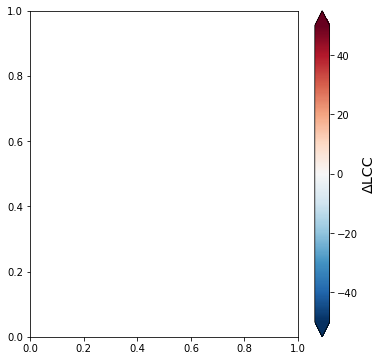

In [85]:
plt.figure(figsize = (6,6))
plt.colorbar(cbar, extend = 'both', label = 'ΔLCC')
fig.savefig('Figures/FigS3acbar.png', dpi = 300, format = 'png')


/tmp/ipykernel_2734536/1344757586.py:94: UserWarning: linewidths is ignored by contourf
  ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,


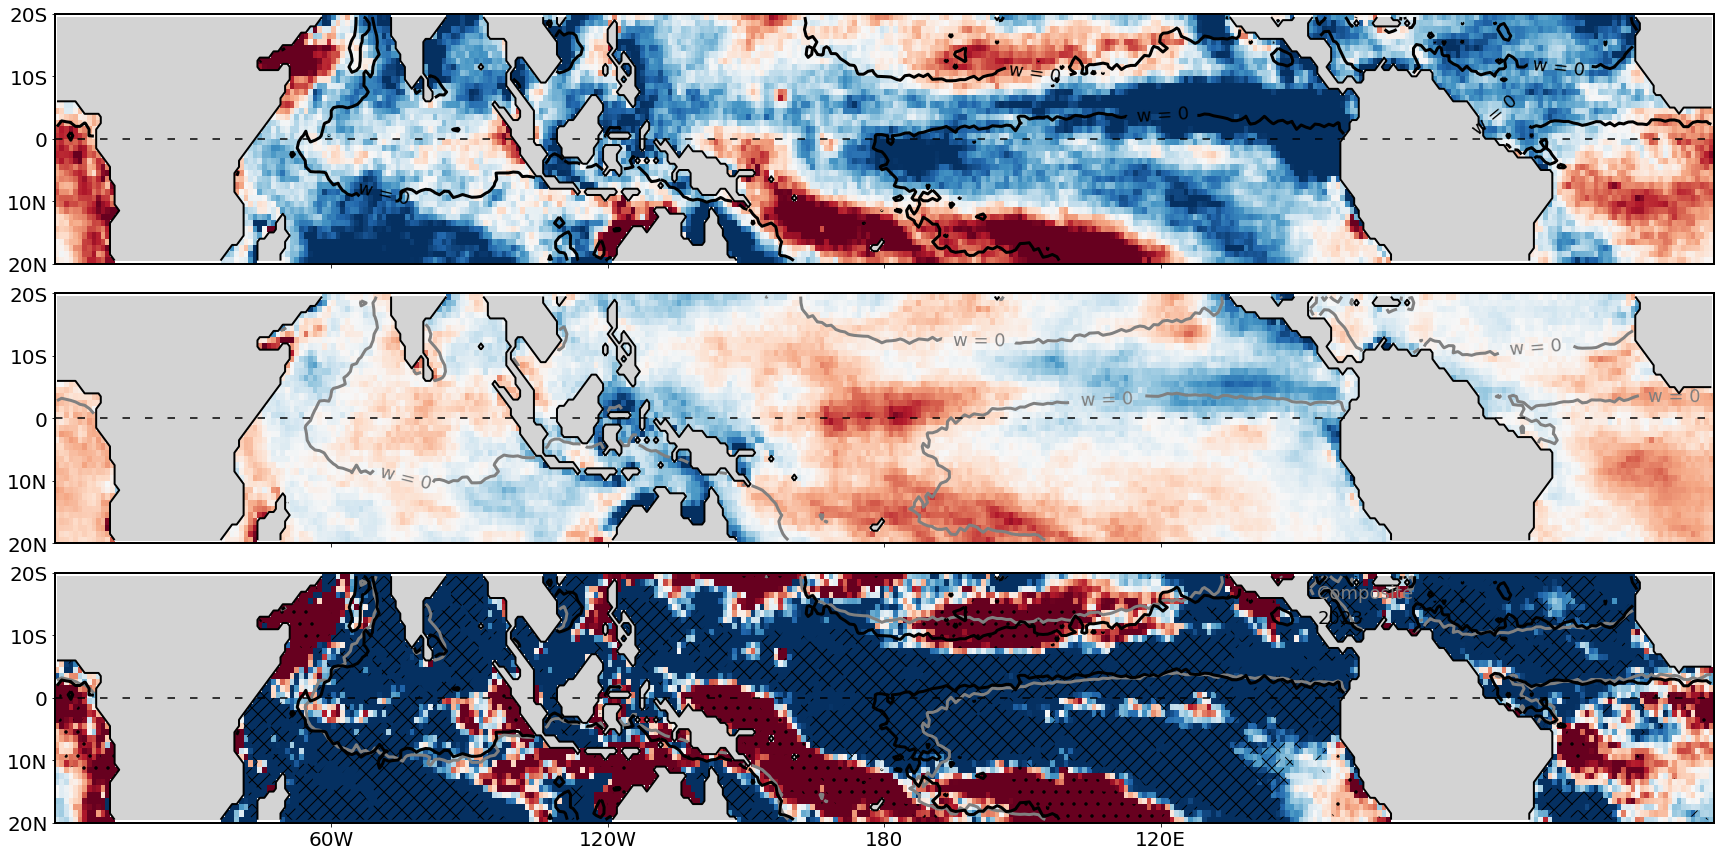

In [137]:
fig, axes = plt.subplots(3,1, figsize = (24,12), sharex = True)


cbar = d_2023.lcc.plot(cmap = 'RdBu_r', vmin = -.25, vmax = .25, ax = axes[0], add_colorbar = False)

# Plot the contour
CS1 = w2023.w.plot.contour(levels=[-0.0], ax=axes[0], colors = 'k', linewidths = 3)
axes[0].clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=18)
axes[0].set_title('')

#-----------------------------


cbar = d_composite.mean('year').lcc.plot(cmap = 'RdBu_r', vmin = -.25, vmax = .25,add_colorbar = False, ax = axes[1])

# Plot the contour
CS1 = wcomposite.w.plot.contour(levels=[-0.0], ax=axes[1], colors = 'grey', linewidths = 3)
axes[1].clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=18)
axes[1].set_title('')

#---------------------
cbar = diff.lcc.plot(cmap = 'RdBu_r', vmin = -.25, vmax = .25, add_colorbar = False)#label=r'$\Delta lcc [K]$')

# Plot the contour
CS1 = wcomposite.w.plot.contour(levels=[-0.0], ax=axes[2], colors = 'grey', linewidths = 3)
CS2 = w2023.w.plot.contour(levels=[-0.0], ax=axes[2], colors = 'k', linewidths = 3)
#axes[2].clabel(CS1, CS1.levels, inline=True, fmt={0:'composite'}, fontsize=12);
#axes[2].clabel(CS2, CS2.levels, inline=True, fmt={0:'2023'}, fontsize=12);
axes[2].set_title('')

#------------------significance masking

# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['//'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)

# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_all_five_high,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['.'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


"""# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_at_least_four_high,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['.'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)
"""
for ax in axes: 
    #ax.set_xlim(40, 290)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticks(ax.get_yticks()[::2])
    
    xtick_position = [60, 120, 180, 240] 
    xtick_labels = [ '60W', '120W', '180', '120E']
    ax.set_xticks(ticks = xtick_position,)
    ax.set_xticklabels(xtick_labels, fontsize = 20)
    ax.set_yticklabels(['20N', '10N', '0', '10S', '20S'], fontsize=20)
    
    #ax.spines[:].set_visible(False)
    ax.spines[:].set_linewidth(2)

#contours for ocean
for ax in axes:  
    ax.contour(ocean_mask.lon, ocean_mask.lat, ocean_mask,
               levels=[0.5], colors='black', linewidths=2)
    ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,
                   levels=[0,0.5], colors='lightgrey', linewidths=2)


    
    
# Manually add a text box with "Composite" in grey and "2023" in black
axes[2].text(274, 16, "Composite", color="grey", fontsize=18, fontweight="normal")
axes[2].text(274, 12, "2023", color="black", fontsize=18, fontweight="normal")

#equator lines
axes[0].axhline(0, linestyle=(0, (5, 10)), c = 'k')
axes[1].axhline(0, linestyle=(0, (5, 10)), c = 'k')
axes[2].axhline(0, linestyle=(0, (5, 10)), c = 'k')


plt.tight_layout()

/tmp/ipykernel_2734536/1973371528.py:2: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  plt.colorbar(cbar, extend = 'both', label = 'ΔLCC')


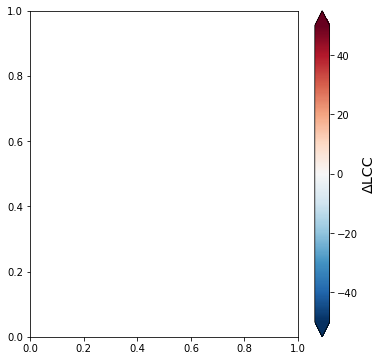

In [150]:
plt.figure(figsize = (6,6))
plt.colorbar(cbar, extend = 'both', label = 'ΔLCC [%]')

# hcc Map

In [86]:
fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w500 = decode_time(fp).sel(lat = slice(20, -20))#,lon= slice(110, 260))

w500 = w500.where(ocean_mask)


In [87]:
w500 = w500.where((w500.time.dt.month<=9)& (w500.time.dt.month>=4)).groupby('time.year').mean('time')
w2023 = w500.sel(year = 2023)
wcomposite = w500.where(w500.year.isin(composite_years), drop = True).mean('year')
wdiff = w500.where(w500.year.isin(composite_years), drop = True).mean('year')


In [88]:

fp  = '/data/jmex/ERA5/monthly/clouds/era5_clouds.nc'

clouds = xr.open_dataset(fp).sel(latitude = slice(20, -20), valid_time = slice('1979', '2024-10'))

clouds = clouds.drop(['expver', 'number'])
clouds = clouds.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})
clouds['lon'] = (clouds['lon']+360)%360
clouds = clouds.sortby('lon')

In [89]:
hcc = clouds.where(ocean_mask)#.drop_vars(['hcc', 'mcc', 'tcc'])

In [90]:
weights = np.cos(np.deg2rad(hcc.lat))

#yearly average Jan-Sept
hcc_y = hcc.where((hcc.time.dt.month<9) & (hcc.time.dt.month>=4)).groupby('time.year').mean()

#change in hcc_y
d_hcc = hcc_y - hcc_y.roll(year = 1)

In [91]:
d_2023 = d_hcc.sel(year = 2023)
#d_2023 = 100*d_2023/clim.hcc

In [92]:
d_composite = d_hcc.where(d_hcc.year.isin(composite_years), drop = True)
#d_composite = 100*d_composite/clim.hcc

In [93]:
diff = d_2023-d_composite.mean('year')


## mask to check comparision

In [94]:
comparision = d_2023.hcc<d_composite.hcc
mask_all_five = comparision.all(dim = 'year')
mask_at_least_four = comparision.sum(dim = 'year') >=5

In [95]:
comparision_high = d_2023.hcc>d_composite.hcc
mask_all_five_high = comparision_high.all(dim = 'year')
mask_at_least_four_high = comparision_high.sum(dim = 'year') >=5

/tmp/ipykernel_821071/729405470.py:94: UserWarning: linewidths is ignored by contourf
  ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,


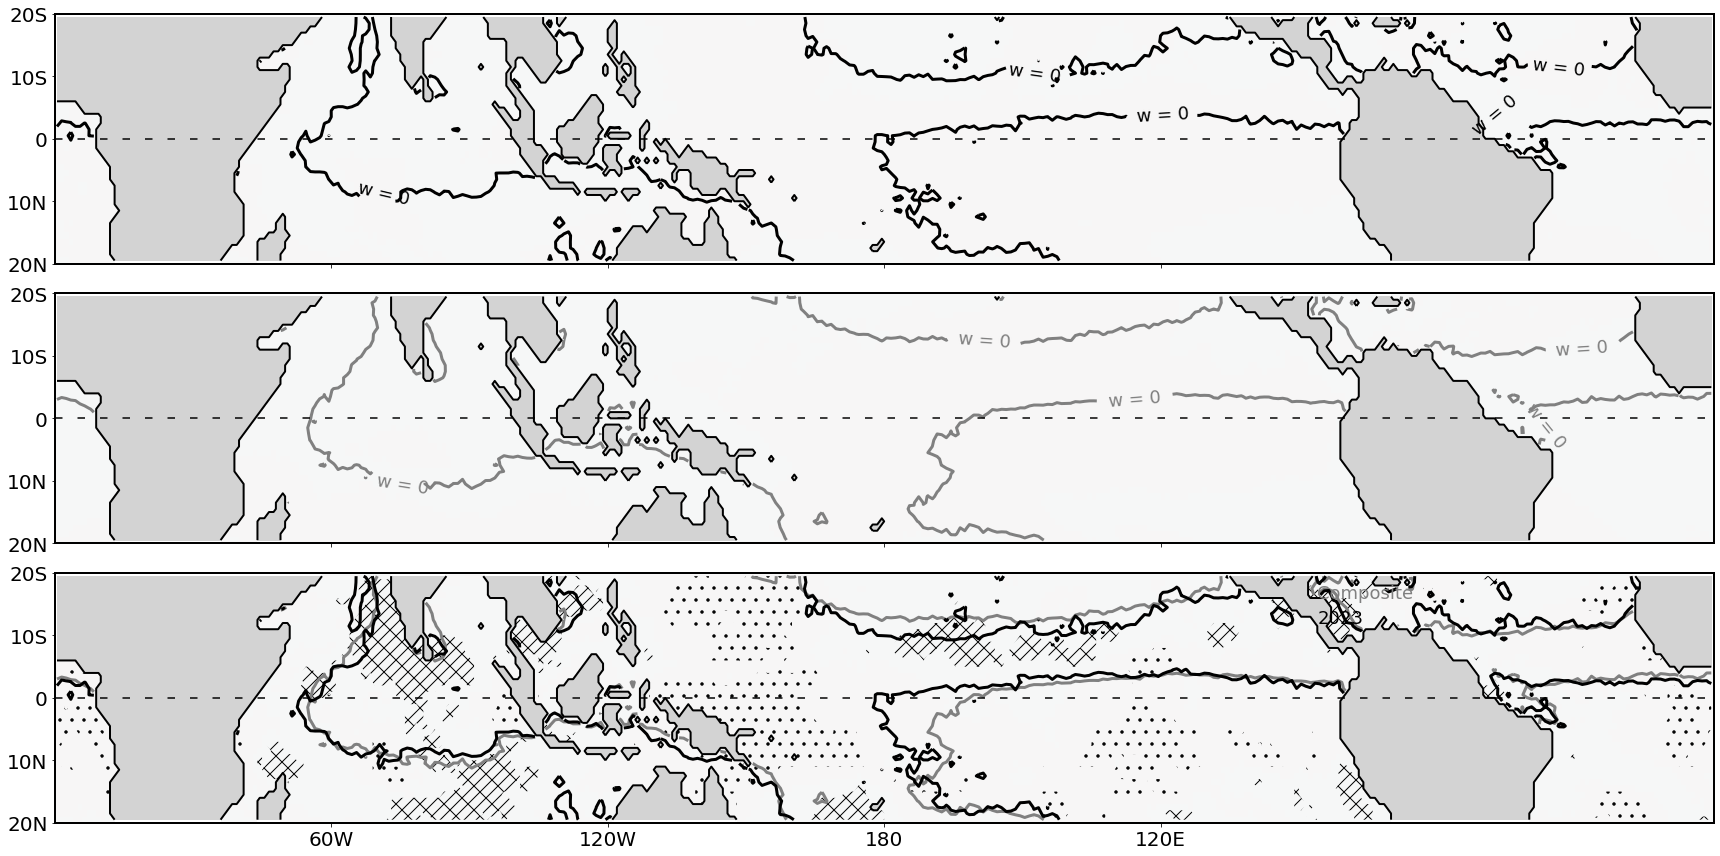

In [96]:
fig, axes = plt.subplots(3,1, figsize = (24,12), sharex = True)


cbar = d_2023.hcc.plot(cmap = 'RdBu_r', vmin = -50, vmax = 50, ax = axes[0], add_colorbar = False)

# Plot the contour
CS1 = w2023.w.plot.contour(levels=[-0.0], ax=axes[0], colors = 'k', linewidths = 3)
axes[0].clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=18)
axes[0].set_title('')

#-----------------------------


cbar = d_composite.mean('year').hcc.plot(cmap = 'RdBu_r', vmin = -50, vmax = 50,add_colorbar = False, ax = axes[1])

# Plot the contour
CS1 = wcomposite.w.plot.contour(levels=[-0.0], ax=axes[1], colors = 'grey', linewidths = 3)
axes[1].clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=18)
axes[1].set_title('')

#---------------------
cbar = diff.hcc.plot(cmap = 'RdBu_r', vmin = -50, vmax = 50, add_colorbar = False)#label=r'$\Delta hcc [K]$')

# Plot the contour
CS1 = wcomposite.w.plot.contour(levels=[-0.0], ax=axes[2], colors = 'grey', linewidths = 3)
CS2 = w2023.w.plot.contour(levels=[-0.0], ax=axes[2], colors = 'k', linewidths = 3)
#axes[2].clabel(CS1, CS1.levels, inline=True, fmt={0:'composite'}, fontsize=12);
#axes[2].clabel(CS2, CS2.levels, inline=True, fmt={0:'2023'}, fontsize=12);
axes[2].set_title('')

#------------------significance masking

# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['//'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)

# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_all_five_high,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['.'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


"""# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_at_least_four_high,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['.'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)
"""
for ax in axes: 
    #ax.set_xlim(40, 290)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticks(ax.get_yticks()[::2])
    
    xtick_position = [60, 120, 180, 240] 
    xtick_labels = [ '60W', '120W', '180', '120E']
    ax.set_xticks(ticks = xtick_position,)
    ax.set_xticklabels(xtick_labels, fontsize = 20)
    ax.set_yticklabels(['20N', '10N', '0', '10S', '20S'], fontsize=20)
    
    #ax.spines[:].set_visible(False)
    ax.spines[:].set_linewidth(2)

#contours for ocean
for ax in axes:  
    ax.contour(ocean_mask.lon, ocean_mask.lat, ocean_mask,
               levels=[0.5], colors='black', linewidths=2)
    ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,
                   levels=[0,0.5], colors='lightgrey', linewidths=2)


    
    
# Manually add a text box with "Composite" in grey and "2023" in black
axes[2].text(274, 16, "Composite", color="grey", fontsize=18, fontweight="normal")
axes[2].text(274, 12, "2023", color="black", fontsize=18, fontweight="normal")

#equator lines
axes[0].axhline(0, linestyle=(0, (5, 10)), c = 'k')
axes[1].axhline(0, linestyle=(0, (5, 10)), c = 'k')
axes[2].axhline(0, linestyle=(0, (5, 10)), c = 'k')


plt.tight_layout()
fig.savefig('Figures/FigS3c.png', dpi = 600, format = 'png')


/tmp/ipykernel_821071/142464187.py:2: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  plt.colorbar(cbar, extend = 'both', label = 'ΔHCC')


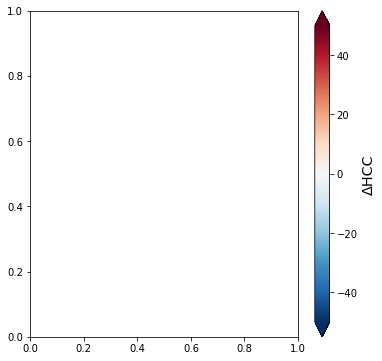

In [97]:
plt.figure(figsize = (6,6))
plt.colorbar(cbar, extend = 'both', label = 'ΔHCC')
fig.savefig('Figures/FigS3ccbar.png', dpi = 300, format = 'png')


/tmp/ipykernel_821071/4118449834.py:94: UserWarning: linewidths is ignored by contourf
  ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,


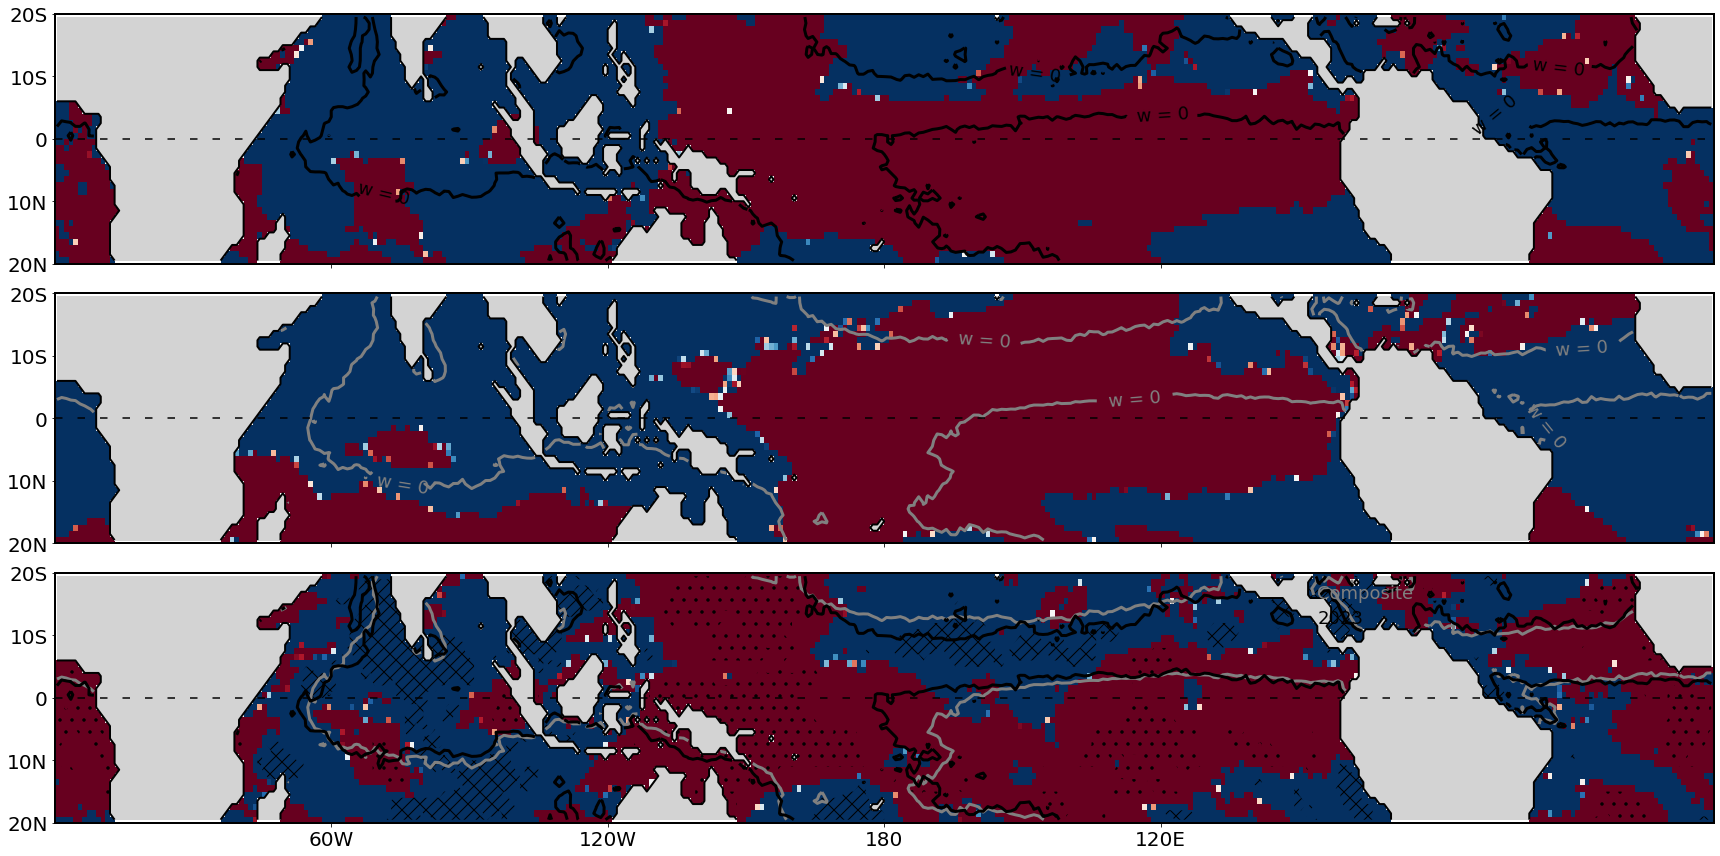

In [70]:
fig, axes = plt.subplots(3,1, figsize = (24,12), sharex = True)


cbar = d_2023.hcc.plot(cmap = 'RdBu_r', vmin = -.25, vmax = .25, ax = axes[0], add_colorbar = False)

# Plot the contour
CS1 = w2023.w.plot.contour(levels=[-0.0], ax=axes[0], colors = 'k', linewidths = 3)
axes[0].clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=18)
axes[0].set_title('')

#-----------------------------


cbar = d_composite.mean('year').hcc.plot(cmap = 'RdBu_r', vmin = -.25, vmax = .25,add_colorbar = False, ax = axes[1])

# Plot the contour
CS1 = wcomposite.w.plot.contour(levels=[-0.0], ax=axes[1], colors = 'grey', linewidths = 3)
axes[1].clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=18)
axes[1].set_title('')

#---------------------
cbar = diff.hcc.plot(cmap = 'RdBu_r', vmin = -.25, vmax = .25, add_colorbar = False)#label=r'$\Delta hcc [K]$')

# Plot the contour
CS1 = wcomposite.w.plot.contour(levels=[-0.0], ax=axes[2], colors = 'grey', linewidths = 3)
CS2 = w2023.w.plot.contour(levels=[-0.0], ax=axes[2], colors = 'k', linewidths = 3)
#axes[2].clabel(CS1, CS1.levels, inline=True, fmt={0:'composite'}, fontsize=12);
#axes[2].clabel(CS2, CS2.levels, inline=True, fmt={0:'2023'}, fontsize=12);
axes[2].set_title('')

#------------------significance masking

# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['//'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)

# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_all_five_high,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['.'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


"""# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_at_least_four_high,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['.'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)
"""
for ax in axes: 
    #ax.set_xlim(40, 290)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticks(ax.get_yticks()[::2])
    
    xtick_position = [60, 120, 180, 240] 
    xtick_labels = [ '60W', '120W', '180', '120E']
    ax.set_xticks(ticks = xtick_position,)
    ax.set_xticklabels(xtick_labels, fontsize = 20)
    ax.set_yticklabels(['20N', '10N', '0', '10S', '20S'], fontsize=20)
    
    #ax.spines[:].set_visible(False)
    ax.spines[:].set_linewidth(2)

#contours for ocean
for ax in axes:  
    ax.contour(ocean_mask.lon, ocean_mask.lat, ocean_mask,
               levels=[0.5], colors='black', linewidths=2)
    ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,
                   levels=[0,0.5], colors='lightgrey', linewidths=2)


    
    
# Manually add a text box with "Composite" in grey and "2023" in black
axes[2].text(274, 16, "Composite", color="grey", fontsize=18, fontweight="normal")
axes[2].text(274, 12, "2023", color="black", fontsize=18, fontweight="normal")

#equator lines
axes[0].axhline(0, linestyle=(0, (5, 10)), c = 'k')
axes[1].axhline(0, linestyle=(0, (5, 10)), c = 'k')
axes[2].axhline(0, linestyle=(0, (5, 10)), c = 'k')


plt.tight_layout()
fig.savefig('Figures/FigS3c.png', dpi = 600, format = 'png')


/tmp/ipykernel_821071/142464187.py:2: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  plt.colorbar(cbar, extend = 'both', label = 'ΔHCC')


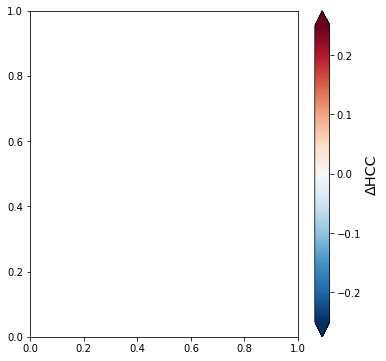

In [71]:
plt.figure(figsize = (6,6))
plt.colorbar(cbar, extend = 'both', label = 'ΔHCC')
fig.savefig('Figures/FigS3ccbar.png', dpi = 600, format = 'png')


# Time Series 

## Clouds


In [98]:
fp  = '/data/jmex/ERA5/monthly/clouds/era5_clouds.nc'

clouds = xr.open_dataset(fp).sel(latitude = slice(20, -20), valid_time = slice('1979', '2024-10'))

clouds = clouds.drop(['expver', 'number'])
clouds = clouds.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})
clouds['lon'] = (clouds['lon']+360)%360
clouds = clouds.sortby('lon')

In [99]:
clouds = clouds.where(ocean_mask)


In [100]:
#cmmpute means
weights = np.cos(np.deg2rad(clouds.lat))
clouds_mean = clouds.weighted(weights).mean(['lat', 'lon']) 


## Bar Code

In [101]:

c_mean = clouds_mean.where((clouds_mean.time.dt.month <=9) & (clouds_mean.time.dt.month >=4)).groupby('time.year').mean('time')

In [102]:
dc_mean = c_mean - c_mean.roll(year = 1)
dc_mean = dc_mean.sel(year = slice(1979, None))

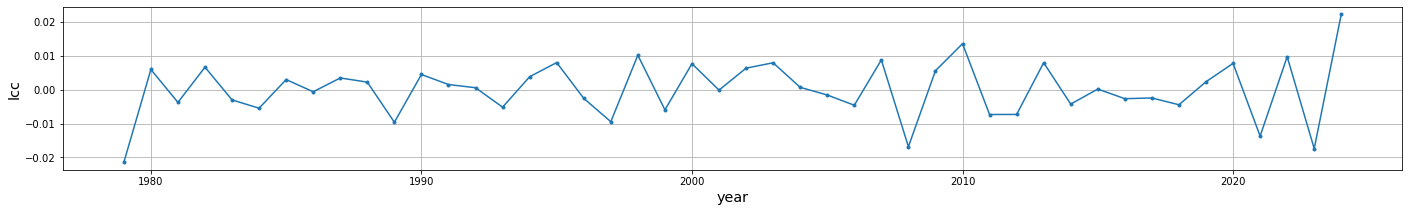

In [103]:
dc_mean.lcc.plot(size = 3, aspect= 8, marker = '.')
plt.grid()

NameError: name 'years' is not defined

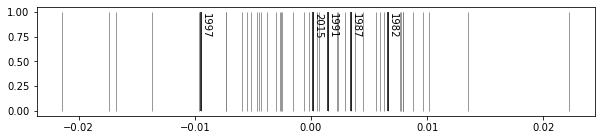

In [104]:

# Assuming dc_mean.lcc and dc_mean.year exist


composite_years = [1982, 1987, 1991, 1997, 2015]
dc_composite = dc_mean.where(dc_mean.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dc_mean.lcc, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dc_composite.lcc, ymin=0, ymax=1, color='black', linewidth=1.5)
for y in dc_composite.year.values: 
    x = dc_mean.sel(year = y).lcc
    ax.annotate(y, (x, 0.75), rotation = 270)

# Plot 2023 in red
if 2023 in years:
    x = dc_mean.sel(year= 2023).lcc
    ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
    ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("LCC")
#ax.set_title("Barcode Plot of dc_mean.lcc")

plt.legend()
plt.show()


In [ ]:
clim = clouds_mean.sel(time = slice('1991', '2020')).groupby('time.month').mean()
clouds_anom = clouds_mean.groupby('time.month')-clim

In [ ]:
clouds_anom = clouds_anom.rolling(time = 6, center = True, min_periods = 3).mean()

## easter clouds

In [ ]:
fp  = '/data/jmex/ERA5/monthly/clouds/era5_clouds.nc'

clouds = xr.open_dataset(fp).sel(latitude = slice(20, -20), valid_time = slice('1979', '2024-10'))

In [ ]:
clouds = clouds.drop(['expver', 'number'])
clouds = clouds.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})
clouds['lon'] = (clouds['lon']+360)%360
clouds = clouds.sortby('lon')
eclouds = clouds.sel(lon = slice(240, 360))

In [ ]:
eclouds = eclouds.where(ocean_mask)


In [ ]:
#cmmpute means
weights = np.cos(np.deg2rad(eclouds.lat))
eclouds_mean = eclouds.weighted(weights).mean(['lat', 'lon']) 


In [ ]:
clim = eclouds_mean.sel(time = slice('1991', '2020')).groupby('time.month').mean()
eclouds_anom = eclouds_mean.groupby('time.month')-clim

In [ ]:
eclouds_anom = eclouds_anom.rolling(time = 6, center = True, min_periods = 3).mean()

# N

In [ ]:
fp = '/data/jmex/CERES/CERES_TOA.nc'
ceres = xr.open_dataset(fp).where(ocean_mask)

clim = ceres.sel(time = slice('1991', '2020')).groupby('time.month').mean()
ceres_anom = ceres.groupby('time.month') - clim

In [ ]:
weights = np.cos(np.deg2rad(ceres_anom.lat))
ceres_ocean_anom = ceres_anom.weighted(weights).mean(['lat', 'lon'])
ceres_ocean_anom = ceres_ocean_anom.rolling(time = 6, center = True, min_periods = 1).mean()

In [ ]:
#all (Sw+lw) TOA; net and clear-sky. downward positive
fp = '/data/jmex/ERA5/monthly/rad_forcing/era5_n.nc'
n= xr.open_dataset(fp)
#change the longitude defintion to 0-360
n['longitude'] = (n['longitude']+360)%360
n = n.sortby('longitude')

#change the longitude defintion to 0-360
n = n.rename({'latitude':'lat', 'longitude':'lon'})
n = n.drop_vars(['number', 'expver'])

n = n.rename({'valid_time':'time'})


#over indo-pac only
n = n.where(ocean_mask)

In [ ]:
#convert to w/m2
n = n/(60**2*24)

In [ ]:
#make rolling mean
n = n.rolling(time = 6, center = True, min_periods = 1).mean().sel(time = slice('1979', '2024-03'))

In [ ]:
weights = np.cos(np.deg2rad(n.lat))

In [ ]:
#total short and longwave
n['n'] = n.tsr+n.ttr

In [ ]:
# Calculate climatology (1990-2020)
n['n_clim'] = n.sel(time=slice('1991-01-01', '2020-12-31')).groupby('time.month').mean('time').n

# Calculate anomalies
n['n_anom'] = n.n.groupby('time.month') - n.n_clim

n['ocean_anom'] = n.n_anom.weighted(weights).mean(['lat', 'lon'])

In [ ]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-20,20))
ocean_mask = masks.open_ocean.isin([2,3]) # mask for tropical indo-pacifi
#ocean_mask = masks.seamask # all tropical oceans

#  LTS

In [ ]:
# Define constants
p0 = 1000  # reference pressure in hPa
R = 287.05  # specific gas constant for dry air in J/(kg*K)
cp = 1005  # specific heat at constant pressure for dry air in J/(kg*K)

def convert_to_potential_temperature(T, p):
    """
    Convert temperature to potential temperature.
    
    Parameters:
    T (xarray.DataArray): Temperature in K
    p (xarray.DataArray): Pressure in hPa
    
    Returns:
    xarray.DataArray: Potential temperature in K
    """
    return T * (p0 / p) ** (R / cp)

In [ ]:
fp = '/data/jmex/ERA5/monthly/temp_pressure/era5_t79.nc'
t1000 = xr.open_dataset(fp).sel(latitude = slice(20, -20), 
                           pressure_level = 1000,
                            valid_time = slice('1979', '2024-10')).drop(['pressure_level', 'expver', 'number'],)
t700 = xr.open_dataset(fp).sel(latitude = slice(20, -20), 
                           pressure_level = 700,
                              valid_time = slice('1979', '2024-10')).drop(['pressure_level', 'expver', 'number'])


#change the longitude defintion to 0-360
t700['longitude'] = (t700['longitude']+360)%360
t700 = t700.sortby('longitude')

#change the longitude defintion to 0-360
t1000['longitude'] = (t1000['longitude']+360)%360
t1000 = t1000.sortby('longitude')


In [ ]:
t1000 = t1000.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'}).where(ocean_mask)

In [ ]:
t700 = t700.rename({'latitude':'lat', 'longitude':'lon',  'valid_time':'time'}).where(ocean_mask)

In [ ]:
t700['t'] = convert_to_potential_temperature(t700.t, p = 700)
t1000['t'] = convert_to_potential_temperature(t1000.t, p = 1000)

In [ ]:
#weigthed mean 
weights = np.cos(np.deg2rad(t700.lat))
t700 = t700.weighted(weights).mean(['lat', 'lon'])
t1000 = t1000.weighted(weights).mean(['lat', 'lon'])

In [ ]:
LTS = t700-t1000
clim = LTS.sel(time = slice('1991', '2020')).groupby('time.month').mean()
LTS['anom'] = LTS.t.groupby('time.month') - clim.t

#running mean 
LTS = LTS.rolling(time = 6, center = True, min_periods = 3).mean()

In [ ]:
def detrend_short(ds, var = 'anom'):
    # Assuming 'ds' is your xarray Dataset

    # Filter data to the time range 2000-2020
    time_mask = (ds['time'].dt.year >= 2000) & (ds['time'].dt.year <= 2020)

    # Extract time and anomaly values for the period 1991-2020
    time_values = ds['time'].where(time_mask, drop=True).values
    anom_values = ds[var].where(time_mask, drop=True).values

    # Convert time values to an index (e.g., number of years or months for fitting)
    time_in_index = np.arange(len(time_values))

    # Perform linear regression (time vs anomaly data) to find the trend for 1991-2020
    slope_anom, intercept_anom, _, _, _ = linregress(time_in_index, anom_values)

    # Calculate the trend for the entire time series, but only subtract the trend fitted from 1991-2020
    time_in_index_full = np.arange(len(ds['time'].values))  # Full time index

    # Calculate the trend based on the fitted slope and intercept
    trend_anom = slope_anom * time_in_index_full + intercept_anom

    # Subtract the linear trend from the 'anom' variable
    ds_detrended = ds.copy()
    ds_detrended[var] = ds[var] - trend_anom
    
    return ds_detrended

LTS_detrended = detrend_short(LTS, 'anom')
clouds_anom_detrended = detrend_short(clouds_anom, var = 'lcc')
eclouds_anom_detrended = detrend_short(eclouds_anom, var = 'lcc')

ceres_ocean_anom_detrended = detrend_short(ceres_ocean_anom, var = 'toa_net_all_mon')
n_detrended = detrend_short(n, var = 'ocean_anom')

In [ ]:
fig, axes = plt.subplots(3,1, figsize = (24,15), sharex = True)


#Radiation
axes[0].plot(ceres_ocean_anom_detrended.time, ceres_ocean_anom_detrended.toa_net_all_mon, c = 'r', label = 'CERES')
axes[0].plot(n_detrended.time, n_detrended.ocean_anom, c = 'k', label = 'ERA5')
axes[0].set_ylabel('Radiation [W/m2]', fontsize = 24)
axes[0].legend(loc = 'upper right')

#LTS
axes[1].plot(LTS_detrended.time, LTS_detrended.anom.values, c = 'k')
axes[1].set_ylabel('LTS [K]', fontsize = 24)
#axes[0].axhline(0, c = 'k', linestyle = '-')



#Low Cloud Cover
axes[2].plot(clouds_anom_detrended.time, clouds_anom_detrended.lcc/clouds_anom_detrended.lcc.std(),
             c = 'k', label = 'Indo-Pacific')
axes[1].axhline(0, linestyle = '-', c = 'k')
#axes[2].axhline(3, linestyle = 'dotted', c = 'grey')
#axes[2].axhline(-3, linestyle = 'dotted', c = 'grey')

axes[2].set_ylim(-5,3)

axes[2].set_ylabel('LCC [σ]', fontsize = 24)
axes[2].set_xlabel('Time', fontsize = 24)
axes[2].legend(loc = 'upper left')


#Eastern Low cloud
axeast = axes[2].twinx()
axeast.plot(eclouds_anom_detrended.time, eclouds_anom_detrended.lcc/eclouds_anom_detrended.lcc.std(),
            c = 'green', label = 'Easter Pacific')
axeast.legend(loc = 'upper right')


axeast.set_ylim(-5,3)

axeast.set_ylabel('Eastern LCC [σ]', fontsize = 24)

axes[2].tick_params(axis='x', labelsize = 16)

# Fill the regions for the specified years
for year in composite_years+['2023']:
    start = np.datetime64(f"{year}-04-01")
    end = np.datetime64(f"{year}-09-30")
    for ax in axes:
        ax.axvspan(start, end, color='gray', alpha=0.2)
    
    
for ax in [*axes, axeast]:
    ax.axhline(0, c = 'k', linestyle = '--')
    ax.tick_params(axis='y', labelsize = 16)
    
    ax.spines[:].set_visible(False)
    ax.grid(axis = 'y')
    ax.set_xlim(np.datetime64('1979'), np.datetime64('2025'))
    
    #add colcanic eruption times
    ax.axvline(np.datetime64('1982-04-01'), label = 'El Chichon', c = 'k', linestyle = '--')
    ax.axvline(np.datetime64('1991-06-15'), label = 'Pinatubo', c = 'k', linestyle = ':')
    
axes[1].legend(loc = 'upper right')

